In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

df = pd.read_csv("final_ml_dataset.csv")

target_col = "Label"   # change if needed
y = df[target_col]
X = df.drop(columns=[target_col])

# keep only numeric columns
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=seed
)

lgbm.fit(X_train, y_train)

lgbm_prob = lgbm.predict_proba(X_test)[:,1]

ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

ann_prob = ann.predict(X_test_scaled, verbose=0).ravel()


# 7. HYBRID ENSEMBLE
# Equal weights: 50% ANN + 50% LightGBM

hybrid_prob = (ann_prob + lgbm_prob) / 2

hybrid_pred = (hybrid_prob > 0.5).astype(int)

acc = accuracy_score(y_test, hybrid_pred)
auc = roc_auc_score(y_test, hybrid_prob)
cm = confusion_matrix(y_test, hybrid_pred)

print("Hybrid ANN + LightGBM")
print("Accuracy:", acc)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, hybrid_pred))

[LightGBM] [Info] Number of positive: 294, number of negative: 83
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9689
[LightGBM] [Info] Number of data points in the train set: 377, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779841 -> initscore=1.264739
[LightGBM] [Info] Start training from score 1.264739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

2026-04-16 17:39:49.694211: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-16 17:39:49.694247: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-16 17:39:49.694255: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-16 17:39:49.694579: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 17:39:49.695021: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2026-04-16 17:39:51.094738: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-16 17:39:51.125882: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


10/10 [==============================] - 4s 130ms/step - loss: 0.6171 - accuracy: 0.7409 - val_loss: 0.7158 - val_accuracy: 0.8553
Epoch 2/50
10/10 [==============================] - 0s 9ms/step - loss: 0.4856 - accuracy: 0.8272 - val_loss: 0.6399 - val_accuracy: 0.8421
Epoch 3/50
10/10 [==============================] - 0s 8ms/step - loss: 0.4830 - accuracy: 0.8439 - val_loss: 0.6413 - val_accuracy: 0.8421
Epoch 4/50
10/10 [==============================] - 0s 9ms/step - loss: 0.3878 - accuracy: 0.8704 - val_loss: 0.6279 - val_accuracy: 0.8553
Epoch 5/50
10/10 [==============================] - 0s 8ms/step - loss: 0.3978 - accuracy: 0.8538 - val_loss: 0.5999 - val_accuracy: 0.8421
Epoch 6/50
10/10 [==============================] - 0s 7ms/step - loss: 0.3971 - accuracy: 0.9003 - val_loss: 0.7097 - val_accuracy: 0.8684
Epoch 7/50
10/10 [==============================] - 0s 8ms/step - loss: 0.3441 - accuracy: 0.8904 - val_loss: 0.6449 - val_accuracy: 0.8553
Epoch 8/50
10/10 [===========

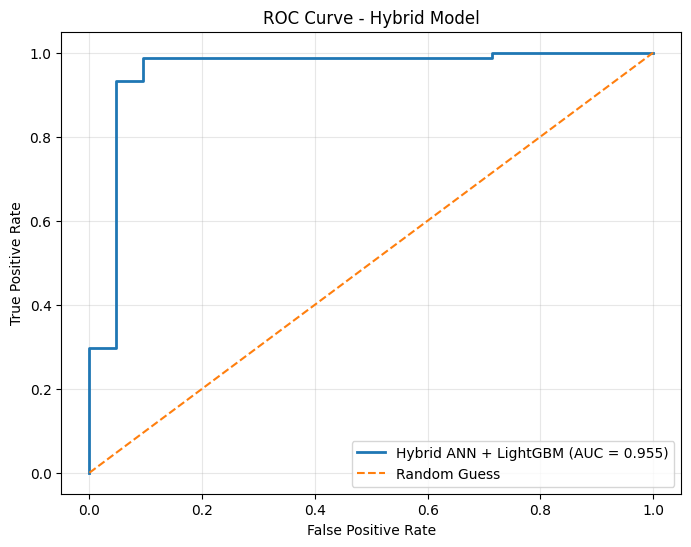

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, hybrid_prob)

# AUC
auc = roc_auc_score(y_test, hybrid_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Hybrid ANN + LightGBM (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], '--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


df = pd.read_csv("final_ml_dataset.csv")

target_col = "Label"   # change if needed
y = df[target_col]
X = df.drop(columns=[target_col])

# keep only numeric columns
X = X.select_dtypes(include=[np.number])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=seed
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=seed
)

lgbm.fit(X_train, y_train)

lgbm_prob = lgbm.predict_proba(X_test)[:,1]


ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

ann_prob = ann.predict(X_test_scaled, verbose=0).ravel()

# HYBRID ENSEMBLE
# Weights: 70% ANN + 30% LightGBM

hybrid_prob = 0.7*lgbm_prob + 0.3*ann_prob
hybrid_pred = (hybrid_prob > 0.5).astype(int)


acc = accuracy_score(y_test, hybrid_pred)
auc = roc_auc_score(y_test, hybrid_prob)
cm = confusion_matrix(y_test, hybrid_pred)

print("Hybrid ANN + LightGBM")
print("Accuracy:", acc)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, hybrid_pred))

[LightGBM] [Info] Number of positive: 294, number of negative: 83
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9689
[LightGBM] [Info] Number of data points in the train set: 377, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779841 -> initscore=1.264739
[LightGBM] [Info] Start training from score 1.264739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

Epoch 1/50
 1/10 [==>...........................] - ETA: 4s - loss: 0.8545 - accuracy: 0.5625

2026-04-16 17:51:58.470206: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


10/10 [==============================] - 1s 47ms/step - loss: 0.6171 - accuracy: 0.7409 - val_loss: 0.7158 - val_accuracy: 0.8553
Epoch 2/50
10/10 [==============================] - 0s 10ms/step - loss: 0.4856 - accuracy: 0.8272 - val_loss: 0.6399 - val_accuracy: 0.8421
Epoch 3/50
10/10 [==============================] - 0s 8ms/step - loss: 0.4830 - accuracy: 0.8439 - val_loss: 0.6413 - val_accuracy: 0.8421
Epoch 4/50
10/10 [==============================] - 0s 9ms/step - loss: 0.3878 - accuracy: 0.8704 - val_loss: 0.6279 - val_accuracy: 0.8553
Epoch 5/50
10/10 [==============================] - 0s 9ms/step - loss: 0.3978 - accuracy: 0.8538 - val_loss: 0.5999 - val_accuracy: 0.8421
Epoch 6/50
10/10 [==============================] - 0s 15ms/step - loss: 0.3971 - accuracy: 0.9003 - val_loss: 0.7097 - val_accuracy: 0.8684
Epoch 7/50
10/10 [==============================] - 0s 11ms/step - loss: 0.3441 - accuracy: 0.8904 - val_loss: 0.6449 - val_accuracy: 0.8553
Epoch 8/50
10/10 [=========

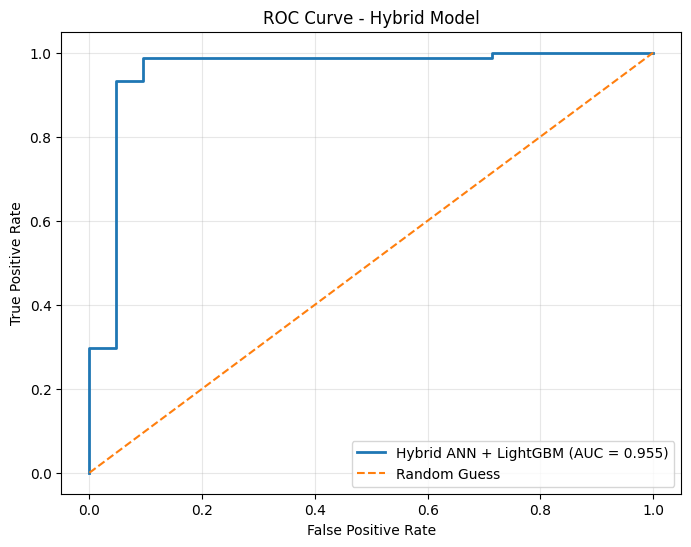

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, hybrid_prob)

# AUC
auc = roc_auc_score(y_test, hybrid_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Hybrid ANN + LightGBM (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], '--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()